<a href="https://colab.research.google.com/github/kevinandrespardo2506-boop/inteligencia-artificial-2/blob/main/Actividaddatosd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo de Precios de Viviendas: Comparación de Modelos de Regresión

Este notebook tiene como objetivo construir y comparar dos modelos de regresión, Regresión Lineal y Árbol de Decisión, para predecir el valor medio de las viviendas (`medv`) utilizando el dataset de precios de casas de Boston.

In [27]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

# url
url_datos = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url_datos)

df.head()
print("Dimensiones del dataset:", df.shape)

print(df.isnull().sum())

# variable objetivo
y = df['medv']

X = df.drop(columns=['medv'])

# características seleccionadas
print("Variables predictoras:", list(X.columns))
# Impor train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprimo la cantidad de filas en cada bloque para constatar la proporción 80/20
print(f"Datos de entrenamiento: {X_train.shape[0]} registros | Datos de prueba: {X_test.shape[0]} registros")
# train_test_split
from sklearn.model_selection import train_test_split

# 80% de los registros para entrenar y reservo el 20% restante para evaluar el rendimiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# cantidad de filas
print(f"Datos de entrenamiento: {X_train.shape[0]} registros | Datos de prueba: {X_test.shape[0]} registros")
# Import Regresión Lineal
from sklearn.linear_model import LinearRegression

# Importo Árbol de Decisión para regresión
from sklearn.tree import DecisionTreeRegressor

# Instancia  regresión lineal
modelo_lr = LinearRegression()

# Entreno (combinación de coeficientes ponderados)
modelo_lr.fit(X_train, y_train)

# el árbol de decisión (profundidad máxima a 5 para evitar sobreajuste prematuro)
modelo_dt = DecisionTreeRegressor(max_depth=5, random_state=42)

modelo_dt.fit(X_train, y_train)
# Import métricas (Error Absoluto Medio (MAE), Error Cuadrático Medio (MSE) y R-cuadrado (R2))
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Importo numpy
import numpy as np

# predicciones con la regresión lineal
pred_lr = modelo_lr.predict(X_test)

# predicciones con el árbol de decisión
pred_dt = modelo_dt.predict(X_test)

# Calculo el error absoluto medio de la regresión lineal para ver el desvío promedio en dólares/moneda local
mae_lr = mean_absolute_error(y_test, pred_lr)

# Calculo la raíz del error cuadrático medio de la regresión lineal, sensible a errores grandes o atípicos
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

# Calculo el coeficiente de determinación R2 de la regresión lineal para saber cuánta varianza explica
r2_lr = r2_score(y_test, pred_lr)

# Calculo el error absoluto medio del árbol de decisión
mae_dt = mean_absolute_error(y_test, pred_dt)

# Calculo el RMSE del árbol de decisión
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))

# Calculo el R2 del árbol de decisión
r2_dt = r2_score(y_test, pred_dt)
# Construyo un diccionario estructurado para tabular los resultados de ambos enfoques
tabla_comparativa = pd.DataFrame({
    "Métrica": ["MAE (Error Medio Absoluto)", "RMSE (Raíz Error Cuadrático)", "R² (Varianza Explicada)"],
    "Regresión Lineal": [round(mae_lr, 3), round(rmse_lr, 3), round(r2_lr, 3)],
    "Árbol de Decisión": [round(mae_dt, 3), round(rmse_dt, 3), round(r2_dt, 3)]
})

# Imprimo la tabla consolidada para comparar el rendimiento de ambos algoritmos
tabla_comparativa

Dimensiones del dataset: (506, 14)
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64
Variables predictoras: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
Datos de entrenamiento: 404 registros | Datos de prueba: 102 registros
Datos de entrenamiento: 404 registros | Datos de prueba: 102 registros


,Métrica,Regresión Lineal,Árbol de Decisión
0,MAE (Error Medio Absoluto),3.189,2.308
1,RMSE (Raíz Error Cuadrático),4.929,2.925
2,R² (Varianza Explicada),0.669,0.883


In [28]:
# Muestro las primeras 5 filas del DataFrame para verificar que los datos se hayan cargado correctamente.
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [29]:
# Reviso la cantidad de filas y columnas que contiene el conjunto de datos para entender su tamaño.
print("Dimensiones del dataset:", df.shape)

# Verifico si existen valores nulos por columna para saber si es necesario realizar imputación de datos.
# Esto es crucial para la calidad del modelo, ya que muchos algoritmos no manejan valores faltantes.
print("\nValores nulos por columna:\n", df.isnull().sum())

Dimensiones del dataset: (506, 14)

Valores nulos por columna:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [30]:
# Elijo la variable objetivo a predecir; en este caso 'medv' representa el valor medio de la vivienda.
y = df['medv']

# Selecciono las variables predictoras (features); descarto la columna objetivo ('medv') para no sesgar el modelo.
X = df.drop(columns=['medv'])

# Imprimo las características seleccionadas para confirmar que no incluí la respuesta (la variable 'medv').
print("Variables predictoras seleccionadas:", list(X.columns))

Variables predictoras seleccionadas: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']


In [31]:
# Importo la función `train_test_split` de `sklearn.model_selection` para dividir los datos.
# Esta función es esencial para evaluar el rendimiento del modelo en datos no vistos.
from sklearn.model_selection import train_test_split

# Divido el 80% de los registros para entrenar el modelo y reservo el 20% restante para evaluar su rendimiento.
# `test_size=0.2` indica que el 20% de los datos se usará para la prueba.
# `random_state=42` fija la semilla para la aleatoriedad, garantizando que el experimento sea reproducible cada vez que se ejecute.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprimo la cantidad de filas en cada bloque para constatar la proporción 80/20 de la división.
print(f"Datos de entrenamiento: {X_train.shape[0]} registros | Datos de prueba: {X_test.shape[0]} registros")

Datos de entrenamiento: 404 registros | Datos de prueba: 102 registros


In [32]:
# Importo el estimador paramétrico clásico de Regresión Lineal de `sklearn.linear_model`.
from sklearn.linear_model import LinearRegression

# Instancio el modelo de Regresión Lineal con sus configuraciones por defecto.
modelo_lr = LinearRegression()

# Entreno la Regresión Lineal utilizando los datos de entrenamiento (X_train y y_train).
# El modelo encuentra la mejor combinación de coeficientes para minimizar la suma de los errores cuadrados.
modelo_lr.fit(X_train, y_train)

LinearRegression()

In [33]:
# Importo el estimador no paramétrico de Árbol de Decisión para regresión de `sklearn.tree`.
from sklearn.tree import DecisionTreeRegressor

# Instancio el modelo de Árbol de Decisión.
# `max_depth=5` limita la profundidad máxima del árbol a 5 para evitar el sobreajuste (overfitting).
# `random_state=42` asegura la reproducibilidad de los resultados del árbol.
modelo_dt = DecisionTreeRegressor(max_depth=5, random_state=42)

# Entreno el Árbol de Decisión utilizando los datos de entrenamiento.
# El modelo divide recursivamente el espacio de características para minimizar la varianza dentro de cada hoja.
modelo_dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [34]:
# Importo las métricas de evaluación estándar: Error Absoluto Medio (MAE), Error Cuadrático Medio (MSE) y R-cuadrado (R2).
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Importo la librería `numpy` para realizar operaciones numéricas, especialmente para la raíz cuadrada.
import numpy as np

# Genero las predicciones con el modelo de Regresión Lineal sobre el conjunto de datos de prueba.
# Es crucial usar X_test, ya que estos datos el modelo nunca los vio durante el entrenamiento.
pred_lr = modelo_lr.predict(X_test)

# Genero las predicciones con el modelo de Árbol de Decisión sobre el mismo conjunto de prueba.
pred_dt = modelo_dt.predict(X_test)

In [35]:
# ----- Evaluación del Modelo de Regresión Lineal -----

# Calculo el Error Absoluto Medio (MAE) para la Regresión Lineal.
# Este métrica indica la diferencia promedio absoluta entre las predicciones y los valores reales, en las mismas unidades que la variable objetivo.
mae_lr = mean_absolute_error(y_test, pred_lr)

# Calculo el Error Cuadrático Medio (MSE) y luego su raíz (RMSE) para la Regresión Lineal.
# El RMSE es sensible a errores grandes y está en las mismas unidades que la variable objetivo, facilitando la interpretación.
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

# Calculo el coeficiente de determinación R-cuadrado (R2) para la Regresión Lineal.
# El R2 indica la proporción de la varianza de la variable dependiente que es predecible a partir de las variables independientes (0 a 1).
r2_lr = r2_score(y_test, pred_lr)

In [36]:
# ----- Evaluación del Modelo de Árbol de Decisión -----

# Calculo el Error Absoluto Medio (MAE) para el Árbol de Decisión.
mae_dt = mean_absolute_error(y_test, pred_dt)

# Calculo el Error Cuadrático Medio (MSE) y luego su raíz (RMSE) para el Árbol de Decisión.
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))

# Calculo el coeficiente de determinación R-cuadrado (R2) para el Árbol de Decisión.
r2_dt = r2_score(y_test, pred_dt)

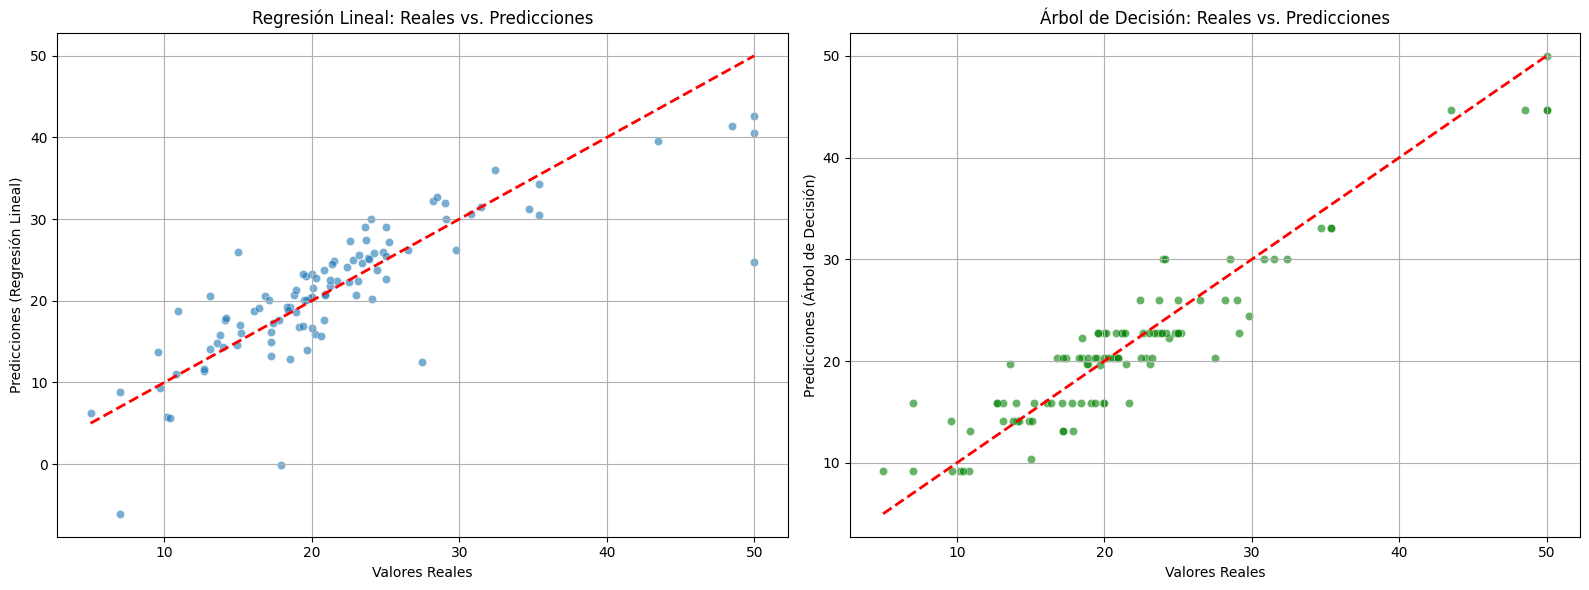

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una figura con dos subplots para comparar los modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot para Regresión Lineal
sns.scatterplot(x=y_test, y=pred_lr, ax=axes[0], alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Regresión Lineal: Reales vs. Predicciones')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones (Regresión Lineal)')
axes[0].grid(True)

# Plot para Árbol de Decisión
sns.scatterplot(x=y_test, y=pred_dt, ax=axes[1], alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Árbol de Decisión: Reales vs. Predicciones')
axes[1].set_xlabel('Valores Reales')
axes[1].set_ylabel('Predicciones (Árbol de Decisión)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [38]:
# Construyo un diccionario estructurado para tabular los resultados de ambos enfoques.
# Esto permite una comparación clara y concisa de las métricas de cada modelo.
tabla_comparativa = pd.DataFrame({
    "Métrica": ["MAE (Error Medio Absoluto)", "RMSE (Raíz Error Cuadrático)", "R² (Varianza Explicada)"],
    "Regresión Lineal": [round(mae_lr, 3), round(rmse_lr, 3), round(r2_lr, 3)],
    "Árbol de Decisión": [round(mae_dt, 3), round(rmse_dt, 3), round(r2_dt, 3)]
})

# Imprimo la tabla consolidada para comparar el rendimiento de ambos algoritmos de manera directa.
tabla_comparativa

,Métrica,Regresión Lineal,Árbol de Decisión
0,MAE (Error Medio Absoluto),3.189,2.308
1,RMSE (Raíz Error Cuadrático),4.929,2.925
2,R² (Varianza Explicada),0.669,0.883


## Análisis Comparativo de Rendimiento de Modelos

Al analizar la tabla comparativa, podemos observar las siguientes conclusiones:

*   **Error Absoluto Medio (MAE):** El Árbol de Decisión (`2.308`) tiene un MAE significativamente menor que la Regresión Lineal (`3.189`). Esto indica que, en promedio, las predicciones del Árbol de Decisión están más cerca de los valores reales de las viviendas, con una desviación promedio de aproximadamente $2,308 vs $3,189 para la Regresión Lineal.

*   **Raíz del Error Cuadrático Medio (RMSE):** Similar al MAE, el RMSE del Árbol de Decisión (`2.925`) es considerablemente menor que el de la Regresión Lineal (`4.929`). Un RMSE menor sugiere que el Árbol de Decisión maneja mejor los errores grandes o atípicos, lo que lo hace un modelo más robusto en este aspecto.

*   **R² (Varianza Explicada):** El coeficiente R² del Árbol de Decisión (`0.883`) es mucho más alto que el de la Regresión Lineal (`0.669`). Esto significa que el Árbol de Decisión es capaz de explicar aproximadamente el 88.3% de la varianza en el precio de las viviendas, mientras que la Regresión Lineal solo explica el 66.9%. Un R² más alto indica un mejor ajuste del modelo a los datos.

**Conclusión:**

Basándonos en estas métricas, el **Modelo de Árbol de Decisión** ha demostrado un rendimiento superior en este dataset para la predicción de precios de viviendas en comparación con el Modelo de Regresión Lineal. Ofrece predicciones más precisas (menor MAE y RMSE) y explica una mayor proporción de la variabilidad en los precios (mayor R²). Esto podría deberse a la capacidad de los árboles de decisión para capturar relaciones no lineales y complejas en los datos, algo que la regresión lineal, por su naturaleza, no puede hacer.

In [39]:
# Muestro nuevamente la tabla comparativa de rendimiento para visualizarla de forma clara en el notebook.
display(tabla_comparativa)

,Métrica,Regresión Lineal,Árbol de Decisión
0,MAE (Error Medio Absoluto),3.189,2.308
1,RMSE (Raíz Error Cuadrático),4.929,2.925
2,R² (Varianza Explicada),0.669,0.883
